# Joint Energy-Based Model (JEM) Pipeline Execution (Chunked)

This notebook demonstrates the end-to-end execution of the Tabular JEM architecture for the Home Credit Default Risk dataset using the **memory-bounded chunked training pipeline**.

It covers:
1. Data Export (Chunked)
2. Streaming Scaler Fit & Chunked Autoencoder Pre-Training
3. Chunked Latent Z Generation
4. JEM Latent Training (Iterable Dataset)
5. Diagnostics & Visualizations
6. Model Persistence for Inference
7. Inference and Submission

In [1]:


import os
import sys
import torch
import numpy as np
import polars as pl
from pathlib import Path
from IPython.display import Image, display

KAGGLE_DATA = "/kaggle/input/competitions/home-credit-credit-risk-model-stability"
KAGGLE_WORKING = "/kaggle/working/"

# Ensure the 'src' module can be imported
workspace_dir = os.path.abspath('..')
sys.path.append(workspace_dir)
os.chdir(KAGGLE_WORKING)  # Important to make relative paths match pipeline scripts!

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

BUNDLE_PATH = "/kaggle/input/datasets/radema/jem-house-stability"

if BUNDLE_PATH not in sys.path:
    sys.path.append(BUNDLE_PATH)


In [17]:
TRAIN_SAMPLE_RATIO=.3

# autoencoder
AE_EPOCHS = 10
AE_LATENT_DIM = 128

#joint energy model
HIDDEN_DIMS = [128, 64, 32]
JEM_EPOCHS = 10

## 1. Phase 0: Data Export (Chunked)
We run the polars data pipeline to export the processed features into numbered Parquet chunks instead of a single giant file to avoid OOM errors.

In [18]:
from src.data.pipeline import run_pipeline
from src.data.config import DataPipelineConfig

# Make sure this is the path to the ACTUAL competition parquet files on Kaggle
# UPDATE THIS LINE
KAGGLE_DATA = "/kaggle/input/competitions/home-credit-credit-risk-model-stability/parquet_files/train" 

os.makedirs(f"{KAGGLE_WORKING}/data/processed/chunks", exist_ok=True)
os.makedirs(f"{KAGGLE_WORKING}/data/processed/latent_chunks", exist_ok=True)
os.makedirs(f"{KAGGLE_WORKING}/models/artifacts", exist_ok=True)

cfg = DataPipelineConfig(
    data_dir=KAGGLE_DATA,         
    sample_ratio=TRAIN_SAMPLE_RATIO,             
    cache_dir=f"{KAGGLE_WORKING}/.cache",
    artifact_dir=f"{KAGGLE_WORKING}/models/artifacts", 
    chunk_size=150000,
    chunked_export=True
)

df_rebuilt = run_pipeline(
    config=cfg,
    depth_0_tables=["train_static_0", "train_static_cb_0"],
    depth_1_tables=[
        "train_person_1",
        "train_deposit",
        "train_debitcard",
        "train_other",
    ],
    depth_2_tables=[],
)

print(f"Dynamically Rebuilt Data Shape: {df_rebuilt.shape}")


2026-03-01 14:29:29,411 [INFO] --- Starting Data Pipeline Run (TRAINING Mode) ---
2026-03-01 14:29:29,414 [INFO] Skipping extraction. Assuming files are natively accessible at /kaggle/input/competitions/home-credit-credit-risk-model-stability/parquet_files/train
2026-03-01 14:29:29,415 [INFO] Loading Base Table: train_base
2026-03-01 14:29:29,415 [INFO] Scanning table with wildcard globbing: /kaggle/input/competitions/home-credit-credit-risk-model-stability/parquet_files/train/**/train_base*.parquet
2026-03-01 14:29:29,438 [INFO] Collecting case_id and target columns to calculate stratified split...
2026-03-01 14:29:29,457 [INFO] Splitting case_ids by target value and sampling 30.0% in each group...
2026-03-01 14:29:29,485 [INFO] Retained 457997 records after stratified sampling.
2026-03-01 14:29:29,486 [INFO] Processing Depth-1 Table: train_person_1
2026-03-01 14:29:29,487 [INFO] Scanning table with wildcard globbing: /kaggle/input/competitions/home-credit-credit-risk-model-stability/

Dynamically Rebuilt Data Shape: (457997, 478)


## 2. Phase 1 & 2: Streaming Scaler Fit & Chunked AE Training
Next, we fit the scaler sequentially over chunks using Welford's algorithm to compute the global mean and variance, and then use the `ChunkedParquetDataset` to train the Autoencoder in a memory-bounded way.

In [20]:
from src.model.jem.scaler import TorchStandardScaler
from src.model.jem.data_utils import get_feature_cols, ChunkedParquetDataset
from src.model.autoencoder.model import TabularAutoencoder, AutoencoderLoss
from src.model.autoencoder.train_autoencoder import weighted_mse_loss, _save_artifacts
from torch.utils.data import DataLoader

import json

chunk_dir = Path(f"{KAGGLE_WORKING}/data/processed/chunks")
chunk_paths = sorted(chunk_dir.glob("train_chunk_*.parquet"))

feature_cols = get_feature_cols(df_rebuilt)
input_dim = len(feature_cols)

# Persist feature columns for inference
os.makedirs(f"{KAGGLE_WORKING}/models/artifacts", exist_ok=True)
with open(f"{KAGGLE_WORKING}/models/artifacts/feature_cols.json", "w") as f:
    json.dump(feature_cols, f)
print(f"Saved {len(feature_cols)} feature columns to models/artifacts/feature_cols.json")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using input dimension: {input_dim}")
print(f"Using device: {device}")

# Phase 1: Streaming Scaler
scaler = TorchStandardScaler(num_features=input_dim)
scaler.streaming_fit(chunk_paths, feature_cols)

# Phase 2: AE Training
latent_dim = AE_LATENT_DIM
autoencoder = TabularAutoencoder(input_dim=input_dim, latent_dim=latent_dim).to(device)
ae_optimizer = torch.optim.Adam(autoencoder.parameters(), lr=1e-3, weight_decay=1e-5)

print("Starting Chunked Autoencoder Training...")
epochs_ae = AE_EPOCHS # Quick run for demonstration
for epoch in range(1, epochs_ae + 1):
    train_dataset = ChunkedParquetDataset(
        chunk_paths=chunk_paths,
        feature_cols=feature_cols,
        scaler=scaler,
        shuffle_buffer_size=10000,
        seed=42
    )
    # The IterableDataset set_epoch ensures shuffling shifts across epochs
    train_dataset.set_epoch(epoch)
    train_loader = DataLoader(train_dataset, batch_size=512)
    
    autoencoder.train()
    total_loss = 0.0
    for batch_idx, (x_batch, y_batch, week_batch, weights_batch) in enumerate(train_loader):
        x_batch = x_batch.to(device)
        weights_batch = weights_batch.to(device)
        
        ae_optimizer.zero_grad()
        x_recon, _ = autoencoder(x_batch)
        loss = weighted_mse_loss(x_batch, x_recon, weights_batch)
        loss.backward()
        ae_optimizer.step()
        total_loss += loss.item()
    print(f"AE Epoch [{epoch}/{epochs_ae}] | Training Loss: {total_loss / (batch_idx + 1):.4f}")

# Save artifacts
_save_artifacts(autoencoder, scaler)
#TO DO: control saving directory


Saved 474 feature columns to models/artifacts/feature_cols.json
Using input dimension: 474
Using device: cuda
Starting Chunked Autoencoder Training...
AE Epoch [1/10] | Training Loss: 0.2402
AE Epoch [2/10] | Training Loss: 0.1696
AE Epoch [3/10] | Training Loss: 0.1556
AE Epoch [4/10] | Training Loss: 0.1351
AE Epoch [5/10] | Training Loss: 0.1244
AE Epoch [6/10] | Training Loss: 0.1120
AE Epoch [7/10] | Training Loss: 0.1021
AE Epoch [8/10] | Training Loss: 0.0952
AE Epoch [9/10] | Training Loss: 0.0891


2026-03-01 14:32:59,917 [INFO] Encoder saved to data/processed/encoder.pt
2026-03-01 14:32:59,919 [INFO] Scaler saved to data/processed/scaler.pt


AE Epoch [10/10] | Training Loss: 0.0848


In [22]:
import gc

gc.collect()

0

## 3. Phase 3: Chunked Latent Z Generation
Now we generate the latent space representations individually for each chunk. This ensures we never load the full dataset's latent representation into memory AT ONCE.

In [23]:
from src.model.autoencoder.train_autoencoder import generate_latent_chunks

latent_chunks_dir = f"{KAGGLE_WORKING}/data/processed/latent_chunks"

print("Generating Latent Chunks...")
generate_latent_chunks(
    autoencoder=autoencoder,
    scaler=scaler,
    chunk_paths=chunk_paths,
    feature_cols=feature_cols,
    output_dir=latent_chunks_dir,
    device=device,
    batch_size=512
)
print("Latent chunks generation complete.")


Generating Latent Chunks...


2026-03-01 14:33:10,607 [INFO] Saved /kaggle/working/data/processed/latent_chunks/latent_chunk_001.pt (shape: torch.Size([150000, 128]))
2026-03-01 14:33:11,921 [INFO] Saved /kaggle/working/data/processed/latent_chunks/latent_chunk_002.pt (shape: torch.Size([150000, 128]))
2026-03-01 14:33:13,225 [INFO] Saved /kaggle/working/data/processed/latent_chunks/latent_chunk_003.pt (shape: torch.Size([150000, 128]))
2026-03-01 14:33:13,383 [INFO] Saved /kaggle/working/data/processed/latent_chunks/latent_chunk_004.pt (shape: torch.Size([7997, 128]))


Latent chunks generation complete.


## 4. Phase 4: JEM Latent Training
We use the new `ChunkedLatentDataset` to train the Joint Energy-Based Model using the latent representations computed in the previous step.

In [ ]:
from src.model.jem.config import JEMConfig
from src.model.jem.model import TabularJEM
from src.model.jem.sampler import SGLDReplayBuffer, SGLDSampler
from src.model.jem.loss import JEMLoss
from src.model.jem.train import train_jem_epoch, evaluate_jem
from src.model.jem.data_utils import ChunkedLatentDataset
from torch.utils.data import TensorDataset

jem_config = JEMConfig(
    hidden_dims=HIDDEN_DIMS,
    spectral_norm=True,
    sgld_steps=20,
    sgld_step_size=0.009,
    sgld_sigma=0.03,
    l2_energy_weight=1e-3,
    reinit_freq=0.05,
    shuffle_buffer_size=10000
)

# Initialize Model, Buffer, Sampler
jem_model = TabularJEM(input_dim=latent_dim, num_classes=2, config=jem_config).to(device)
buffer = SGLDReplayBuffer(buffer_size=10000, feature_dim=latent_dim)
sampler = SGLDSampler(config=jem_config)
criterion = JEMLoss(config=jem_config)
jem_optimizer = torch.optim.Adam(jem_model.parameters(), lr=1e-4, weight_decay=1e-5)

# For chunks training
latent_chunk_paths = sorted(Path(latent_chunks_dir).glob("latent_chunk_*.pt"))

# For demo, take last chunk as validation set
val_path = latent_chunk_paths[-1]
val_data = torch.load(val_path, weights_only=False)
val_dataset = TensorDataset(val_data["z"], val_data["y"], val_data["weeks"])
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

train_chunk_paths = latent_chunk_paths[:-1]
if len(train_chunk_paths) == 0:
    train_chunk_paths = latent_chunk_paths # Fallback if only 1 chunk was created

print("Starting JEM Latent Training...")
epochs_jem = JEM_EPOCHS
history = {
    "train_loss": [], "val_stability": [],
    "e_real_train": [], "e_fake_train": [],
    "val_energies": []
}

for epoch in range(1, epochs_jem + 1):
    train_dataset = ChunkedLatentDataset(
        chunk_paths=train_chunk_paths,
        shuffle_buffer_size=jem_config.shuffle_buffer_size,
        seed=42
    )
    train_dataset.set_epoch(epoch)
    train_loader = DataLoader(train_dataset, batch_size=256)
    
    train_logs = train_jem_epoch(jem_model, train_loader, jem_optimizer, criterion, buffer, sampler, device)
    val_logs = evaluate_jem(jem_model, val_loader, device)
    
    history["train_loss"].append(train_logs["loss"])
    stability = val_logs["stability_result"]["stability_metric"]
    history["val_stability"].append(stability)
    history["e_real_train"].append(train_logs["gen_loss"] / 2.0) 
    history["e_fake_train"].append(-train_logs["gen_loss"] / 2.0) 
    
    if epoch == epochs_jem:
        history["val_energies"] = val_logs["energies"]
        final_val_probs = val_logs["probs"]
        final_val_y = val_logs["labels"]
    
    print(f"JEM Epoch [{epoch:02d}/{epochs_jem}] | Loss: {train_logs['loss']:.4f} | Validation Gini Stability: {stability:.4f}")


Starting JEM Latent Training...
JEM Epoch [01/10] | Loss: -52.0797 | Validation Gini Stability: 0.2486
JEM Epoch [02/10] | Loss: -5.6307 | Validation Gini Stability: 0.3219
JEM Epoch [03/10] | Loss: -4.8428 | Validation Gini Stability: 0.3201
JEM Epoch [04/10] | Loss: -4.8799 | Validation Gini Stability: 0.3744
JEM Epoch [05/10] | Loss: -4.8883 | Validation Gini Stability: 0.3455
JEM Epoch [06/10] | Loss: -4.9537 | Validation Gini Stability: 0.3308
JEM Epoch [07/10] | Loss: -4.9355 | Validation Gini Stability: 0.3739


## 5. Phase 5: Diagnostics & Visualizations
Investigate specialized metrics for the JEM model.

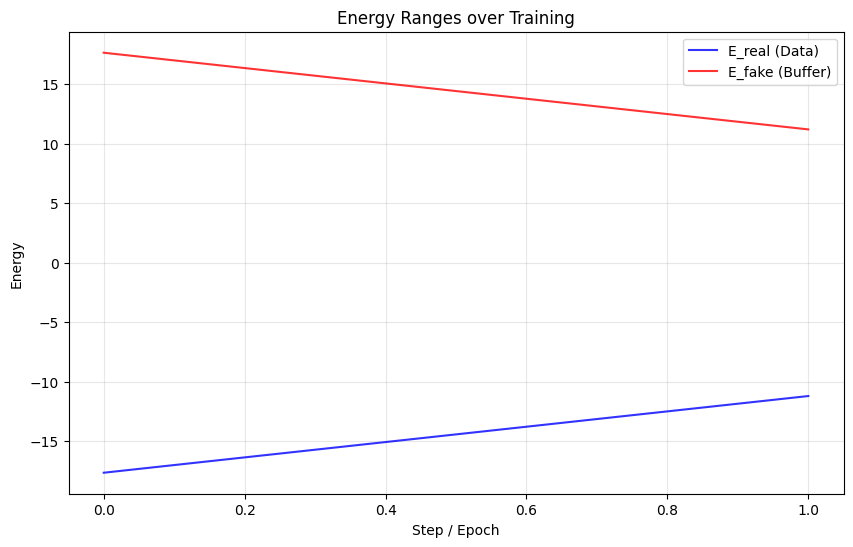

In [9]:
from src.model.jem.diagnostics import JEMDiagnostics

os.makedirs(f"{KAGGLE_WORKING}/docs/assets/", exist_ok=True)

# 1. Energy Ranges over Training
JEMDiagnostics.plot_energy_ranges(
    history["e_real_train"], 
    history["e_fake_train"],
    save_path=f"{KAGGLE_WORKING}/docs/assets/energy_ranges.png"
)
display(Image(filename=f"{KAGGLE_WORKING}/docs/assets/energy_ranges.png"))


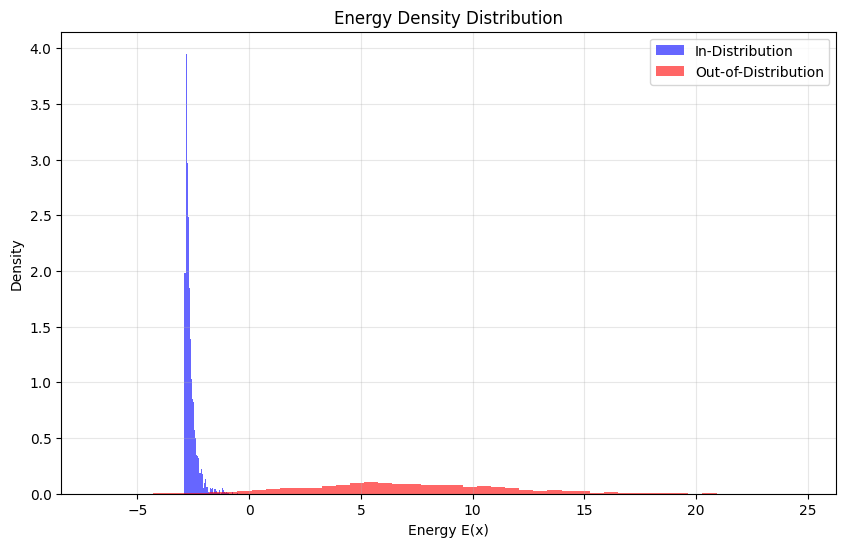

In [10]:
# 2. Energy Density Distribution
simulated_ood = []
jem_model.eval()
with torch.no_grad():
    for x_real, _, _ in val_loader:
        x_real = x_real.to(device)
        x_ood = x_real + torch.randn_like(x_real) * 10.0
        ood_energies = jem_model.compute_energy(x_ood)
        simulated_ood.append(ood_energies.cpu().numpy())

sim_ood_np = np.concatenate(simulated_ood)
JEMDiagnostics.plot_energy_density(
    history["val_energies"], 
    e_out_dist=sim_ood_np, 
    save_path=f"{KAGGLE_WORKING}/docs/assets/energy_density.png"
)
display(Image(filename=f"{KAGGLE_WORKING}/docs/assets/energy_density.png"))


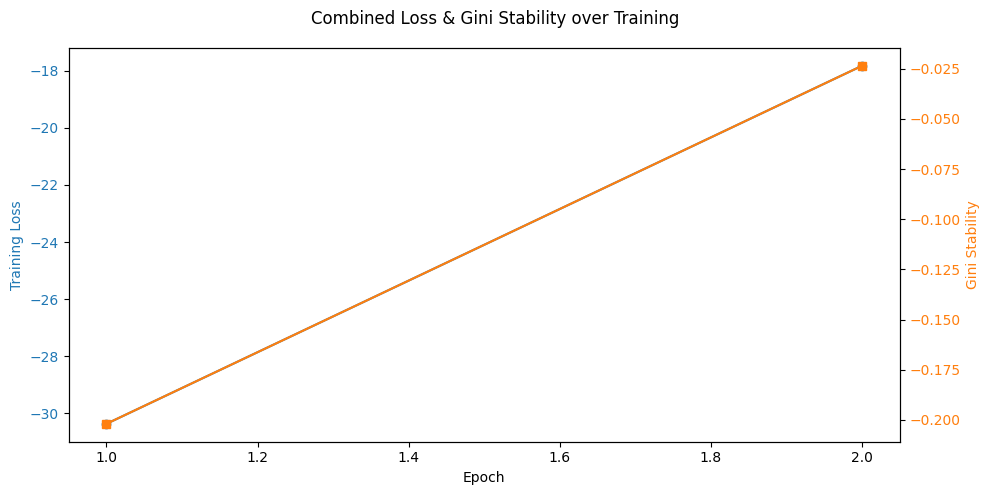

In [11]:
# 3. Combined Loss + Stability
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Training Loss', color='tab:blue')
ax1.plot(range(1, len(history["train_loss"])+1), history["train_loss"], 'o-', color='tab:blue', label='Train Loss')
ax1.tick_params(axis='y', labelcolor='tab:blue')

ax2 = ax1.twinx()
ax2.set_ylabel('Gini Stability', color='tab:orange')
ax2.plot(range(1, len(history["val_stability"])+1), history["val_stability"], 's-', color='tab:orange', label='Val Stability')
ax2.tick_params(axis='y', labelcolor='tab:orange')

fig.suptitle('Combined Loss & Gini Stability over Training')
fig.tight_layout()
plt.savefig("docs/assets/loss_stability.png", bbox_inches='tight')
plt.close()
display(Image(filename=f"{KAGGLE_WORKING}/docs/assets/loss_stability.png"))


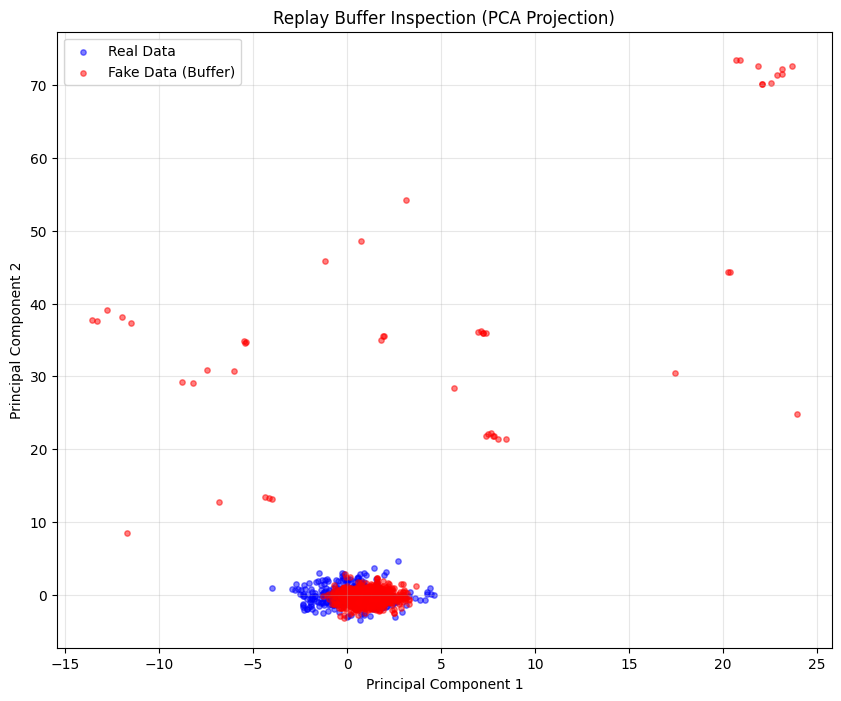

In [12]:
# 4. Replay Buffer Inspection (PCA Projection)
# Ensures the generated SGLD samples are aligned with the data manifold.
last_batch_x, _, _ = next(iter(val_loader))
JEMDiagnostics.inspect_replay_buffer(
    buffer, 
    last_batch_x, 
    save_path=f"{KAGGLE_WORKING}/docs/assets/buffer_inspection.png"
)
display(Image(filename=f"{KAGGLE_WORKING}/docs/assets/buffer_inspection.png"))


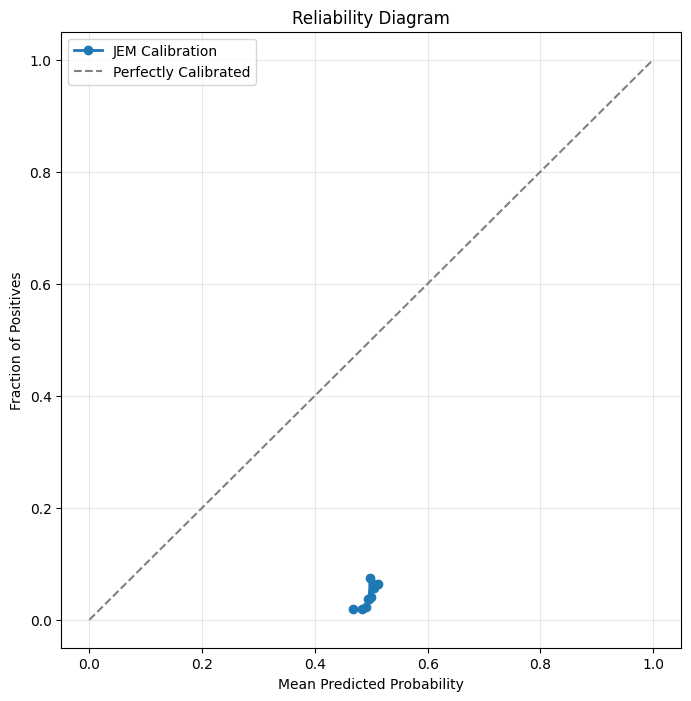

In [13]:
# 5. Reliability Diagram (Calibration)
# Checks if the JEM's predicted probabilities are well-calibrated.
JEMDiagnostics.plot_reliability_diagram(
    final_val_y, 
    final_val_probs,
    save_path=f"{KAGGLE_WORKING}/docs/assets/reliability_diagram.png"
)
display(Image(filename=f"{KAGGLE_WORKING}/docs/assets/reliability_diagram.png"))


## 6. Phase 6: Model Persistence for Inference
Save the final combined LatentJEMWrapper model for standalone inference pipeline.

In [14]:
import shutil
from src.model.jem.model import LatentJEMWrapper

artifact_dir = f"{KAGGLE_WORKING}models/artifacts"
os.makedirs(artifact_dir, exist_ok=True)

# Package Model into wrapper
wrapper = LatentJEMWrapper(scaler, autoencoder.encoder, jem_model)
torch.save(wrapper.state_dict(), os.path.join(artifact_dir, "latent_jem_full.pt"))

# Also save scaler and encoder individually for fallback
torch.save(autoencoder.encoder.state_dict(), os.path.join(artifact_dir, "autoencoder.pth"))
torch.save({
    "num_features": scaler.num_features,
    "eps": getattr(scaler, 'eps', 1e-8),
    "state_dict": scaler.state_dict()
}, os.path.join(artifact_dir, "scaler.pth"))

print(f"Artifacts saved to {artifact_dir}")


Artifacts saved to /kaggle/working//models/artifacts


## 7. Inference and Submission
Final submission generation.

In [15]:
from src.data.pipeline import run_pipeline
from src.data.config import DataPipelineConfig
from src.model.jem.infer import load_inference_pipeline, perform_inference
from src.model.jem.data_utils import get_inference_dataloader, load_feature_cols
import polars as pl
from src.model.jem.config import JEMConfig

KAGGLE_INFERENCE_DATA = "/kaggle/input/competitions/home-credit-credit-risk-model-stability/parquet_files/test" 


test_cfg = DataPipelineConfig(
    data_dir=KAGGLE_INFERENCE_DATA,
    sample_ratio=1.0,
    is_inference=True,
    artifact_dir=f"{KAGGLE_WORKING}models/artifacts"
)

test_df = run_pipeline(
    config=test_cfg,
    depth_0_tables=["test_static_0", "test_static_cb_0"],
    depth_1_tables=["test_person_1", "test_deposit", "test_debitcard", "test_other"],
    depth_2_tables=[]
)

feature_cols = load_feature_cols(f"{KAGGLE_WORKING}/models/artifacts")

# JEMConfig identical to training
jem_config = JEMConfig(
    artifact_dir=f"{KAGGLE_WORKING}/models/artifacts", 
    hidden_dims=HIDDEN_DIMS
)

# Load the inference pipeline
from src.model.autoencoder.model import TabularAutoencoder

scaler_inf = TorchStandardScaler(num_features=len(feature_cols))
scaler_state = torch.load(os.path.join(artifact_dir, "scaler.pth"), map_location=device, weights_only=False)
scaler_inf.load_state_dict(scaler_state["state_dict"])
scaler_inf.to(device)

ae_inf = TabularAutoencoder(input_dim=len(feature_cols), latent_dim=128)
ae_inf.encoder.load_state_dict(torch.load(os.path.join(artifact_dir, "autoencoder.pth"), map_location=device, weights_only=False))
ae_inf.to(device)
ae_inf.eval()

jem_inf = TabularJEM(input_dim=128, num_classes=2, config=jem_config)
wrapper_state = torch.load(os.path.join(artifact_dir, "latent_jem_full.pt"), map_location=device, weights_only=False)
wrapper_inf = LatentJEMWrapper(scaler_inf, ae_inf.encoder, jem_inf)
wrapper_inf.load_state_dict(wrapper_state)
wrapper_inf.to(device)
wrapper_inf.eval()

# In some implementations load_inference_pipeline loads scaler, ae, jem individually. 
# Hence we loaded them iteratively, now perform inference using the original pattern.
loader = get_inference_dataloader(test_df, feature_cols, batch_size=4096)
case_ids, probs, energies = perform_inference(
    scaler=scaler_inf,
    autoencoder=ae_inf,
    jem=jem_inf,
    loader=loader,
    device=device,
    return_energies=True
)

submission_df = pl.DataFrame({"case_id": case_ids, "score": probs})
submission_df.write_csv("./submission.csv")
print(f"Submission generated: submission.csv (Shape: {submission_df.shape})")


2026-03-01 14:26:21,446 [INFO] --- Starting Data Pipeline Run (INFERENCE Mode) ---
2026-03-01 14:26:21,450 [INFO] Skipping extraction. Assuming files are natively accessible at /kaggle/input/competitions/home-credit-credit-risk-model-stability/parquet_files/test
2026-03-01 14:26:21,451 [INFO] Loading Base Table: test_base
2026-03-01 14:26:21,451 [INFO] Scanning table with wildcard globbing: /kaggle/input/competitions/home-credit-credit-risk-model-stability/parquet_files/test/**/test_base*.parquet
2026-03-01 14:26:21,514 [INFO] Process all case_ids for inference.
2026-03-01 14:26:21,515 [INFO] Processing Depth-1 Table: test_person_1
2026-03-01 14:26:21,516 [INFO] Scanning table with wildcard globbing: /kaggle/input/competitions/home-credit-credit-risk-model-stability/parquet_files/test/**/test_person_1*.parquet
2026-03-01 14:26:21,525 [INFO] Processing Depth-1 Table: test_deposit
2026-03-01 14:26:21,525 [INFO] Scanning table with wildcard globbing: /kaggle/input/competitions/home-credit

Submission generated: submission.csv (Shape: (10, 2))
